# Plan 9: Markov movement audit

This notebook reads immutable E9.1 and E9.2 artifacts only. It does not train, resume, or repair a learner. The question is whether accepted EWC updates can yield a calibrated, single-trajectory estimate of population movement before any closed-loop experiment is justified.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'mnist_experiment').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'mnist_experiment').is_dir():
    raise RuntimeError('Run this notebook from within the repository.')

E91 = ROOT / 'cache/mnist_experiment/rotated_mnist/plan9/e9_1/rotated_mnist_plan9_e9_1_anchor_cancellation__replica-0001__b1234a5779ce2e42'
E92 = ROOT / 'cache/mnist_experiment/rotated_mnist/plan9/e9_2/rotated_mnist_plan9_e9_2_smooth_drift_v2__replica-0001__b4c838dcc0b327bf'
for path in (E91, E92):
    if not (path / 'COMPLETED').is_file():
        raise RuntimeError(f'Immutable Plan 9 artifact is incomplete or absent: {path.name}')

def load_json(path):
    return json.loads(path.read_text(encoding='utf-8'))

e91_summary = load_json(E91 / 'summary.json')
e92_summary = load_json(E92 / 'summary.json')
e92_rows = pd.DataFrame(load_json(E92 / 'audit_rows.json'))
print(f"E9.1: {e91_summary['status']} | E9.2: {e92_summary['status']}")

E9.1: inconclusive | E9.2: inconclusive


## E9.1: anchor cancellation

For accepted update $u_t$ and predictable action $\pi_t>0$, define

$$Y_t=\frac{u_t}{\pi_t}, \qquad Z_t=Y_t-(1-\pi_{t-1})Y_{t-1}.$$

Under the local affine EWC model, the realized anchor error cancels and $Z_t=d_t^\star+(\xi_{t+1}-\xi_t)$, apart from EWC-affinity remainder terms. E9.1 compares its Fisher-risk recommendation with the population oracle and the historical trend estimator.

,design,schedule,historical_trend_action_mae,z_action_mae,relative_action_mae_reduction,mean_fisher_cosine,z_clipping_fraction
0,double_lap,linear,0.0862,0.0522,0.3944,-0.0500,0.9057
1,double_lap,sigmoid,0.0557,0.5151,-8.2444,-0.0237,0.2917
2,single_lap,linear,0.0923,0.5240,-4.6744,0.0021,0.2500
3,single_lap,sigmoid,0.0834,0.7547,-8.0479,-0.0428,0.1607


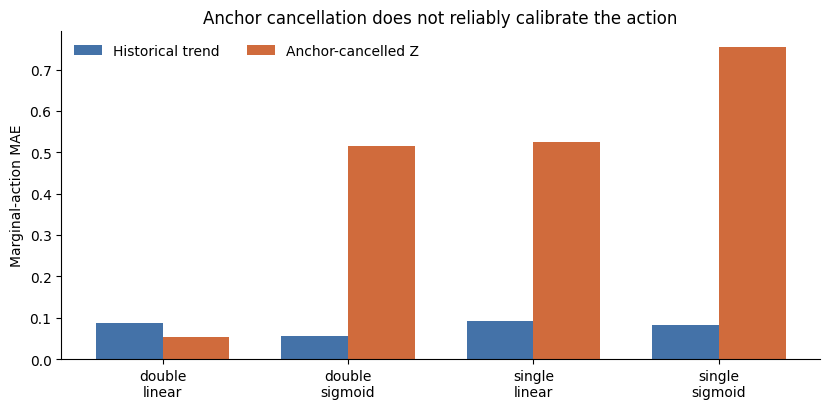

In [2]:
e91 = pd.DataFrame(e91_summary['group_summaries'])
display(e91[[
    'design', 'schedule', 'historical_trend_action_mae', 'z_action_mae',
    'relative_action_mae_reduction', 'mean_fisher_cosine', 'z_clipping_fraction'
]].round(4))

labels = [f"{d.replace('_lap', '')}\n{s}" for d, s in zip(e91.design, e91.schedule)]
x = np.arange(len(e91))
width = 0.36
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(x - width/2, e91.historical_trend_action_mae, width, label='Historical trend', color='#4472A8')
ax.bar(x + width/2, e91.z_action_mae, width, label='Anchor-cancelled Z', color='#D06B3C')
ax.set_xticks(x, labels)
ax.set_ylabel('Marginal-action MAE')
ax.set_title('Anchor cancellation does not reliably calibrate the action')
ax.legend(frameon=False, ncols=2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

E9.1 improves only the linear double-lap group. Mean Fisher cosine remains near zero in every group, so the identity removes the anchor algebraically but does not isolate population movement accurately enough from one realized optimization path.

## E9.2: smooth-drift filtering

A causal vector average $\bar Z_t=\sum_k w_{t,k}Z_k$ is formed before taking its Fisher norm. If $Z_k$ contains $\eta_k=\xi_{k+1}-\xi_k$, adjacent observations share an innovation with opposite signs. For common metric $G_t$, the exact correction is

$$\operatorname{tr}\!\left[G_t\operatorname{Cov}\!\left(\sum_k w_k\eta_k\right)\right]=\sum_j c_j^2\operatorname{tr}(G_t\Sigma_j),$$

where $c=(-w_1,w_1-w_2,\ldots,w_{r-1}-w_r,w_r)$. This is equivalent to retaining the negative adjacent cross-covariances. Selection used calibration only; accuracy and NLL were never consulted.

,design,schedule,historical trend,instantaneous Z,smoothed Z (vector_x2),instantaneous signal MAE,smoothed signal MAE
0,double_lap,linear,0.0862,0.0522,0.0179,7.6172,0.1614
1,double_lap,sigmoid,0.0557,0.5151,0.0971,61.0826,0.8195
2,single_lap,linear,0.0923,0.5240,0.1107,54.8601,0.9771
3,single_lap,sigmoid,0.0834,0.7547,0.1908,611.9164,2.3934


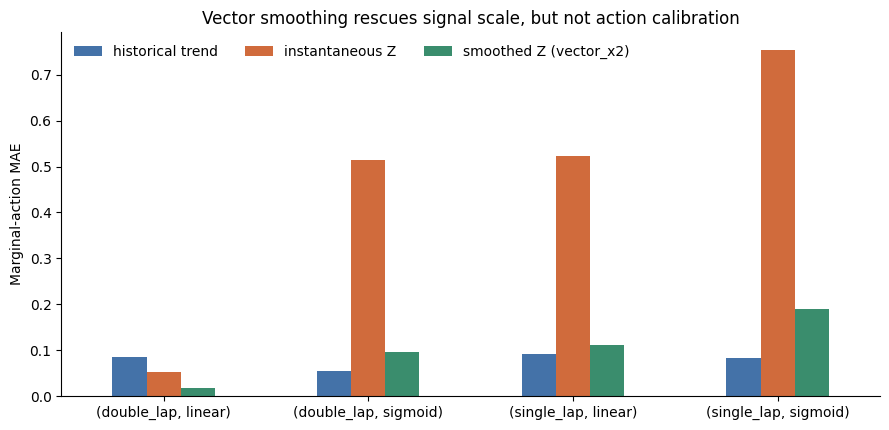

In [3]:
selected_name = e92_summary['selected_estimator']
e92 = pd.DataFrame(e92_summary['group_summaries'])
instant = e92[e92.estimator == 'instantaneous'].set_index(['design', 'schedule'])
selected = e92[e92.estimator == selected_name].set_index(['design', 'schedule'])
comparison = pd.DataFrame({
    'historical trend': selected.historical_action_mae,
    'instantaneous Z': instant.action_mae,
    f'smoothed Z ({selected_name})': selected.action_mae,
    'instantaneous signal MAE': instant.signal_mae,
    'smoothed signal MAE': selected.signal_mae,
}).reset_index()
display(comparison.round(4))

plot_values = comparison.set_index(['design', 'schedule'])[[
    'historical trend', 'instantaneous Z', f'smoothed Z ({selected_name})'
]]
ax = plot_values.plot.bar(figsize=(9.0, 4.4), color=['#4472A8', '#D06B3C', '#3A8D6D'])
ax.set_ylabel('Marginal-action MAE')
ax.set_xlabel('')
ax.set_title('Vector smoothing rescues signal scale, but not action calibration')
ax.legend(frameon=False, ncols=3)
ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

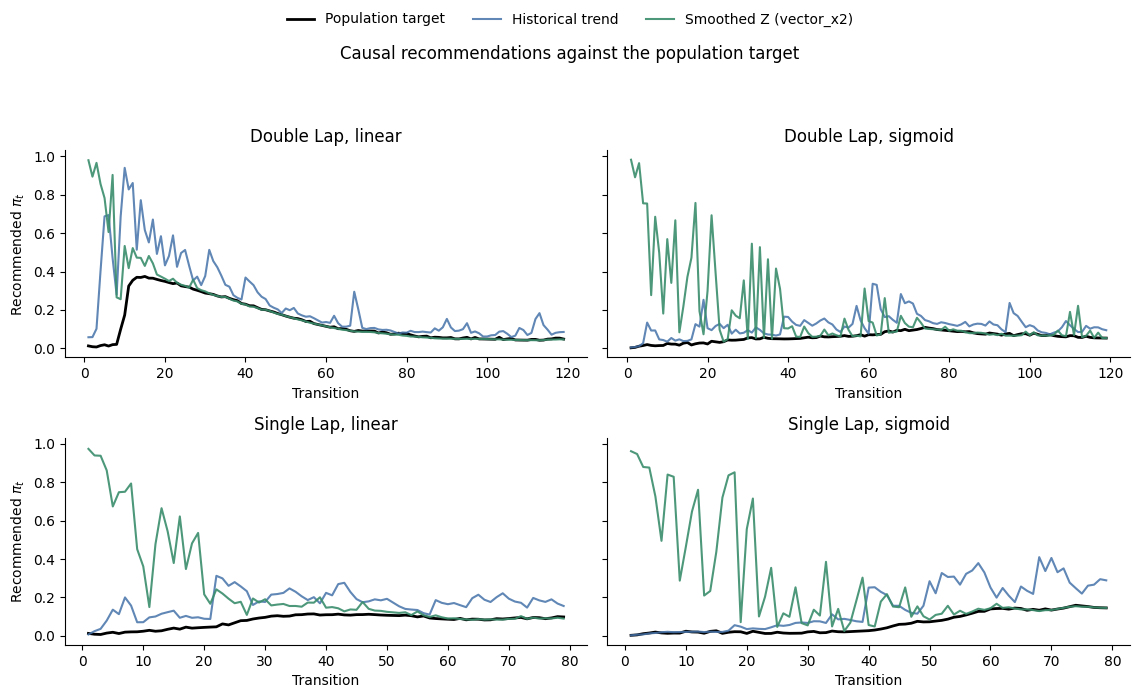

In [4]:
chosen = e92_rows[e92_rows.estimator == selected_name].copy()
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0), sharey=True)
for ax, ((design, schedule), group) in zip(axes.flat, chosen.groupby(['design', 'schedule'], sort=True)):
    group = group.sort_values('step')
    ax.plot(group.step, group.population_pi, color='black', linewidth=2.0, label='Population target')
    ax.plot(group.step, group.historical_trend_pi, color='#4472A8', alpha=.85, label='Historical trend')
    ax.plot(group.step, group.action, color='#3A8D6D', alpha=.9, label=f'Smoothed Z ({selected_name})')
    ax.set_title(f"{design.replace('_', ' ').title()}, {schedule}")
    ax.set_xlabel('Transition')
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].set_ylabel(r'Recommended $\pi_t$')
axes[1, 0].set_ylabel(r'Recommended $\pi_t$')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncols=3, frameon=False)
fig.suptitle('Causal recommendations against the population target', y=.94)
fig.tight_layout(rect=(0, 0, 1, .89))
plt.show()

## Decision

The selected `2x` vector smoother lowers movement-energy MAE in all four groups, confirming that telescoping can suppress substantial update noise. It beats both the instantaneous estimator and historical trend in action MAE in only one group; three were required. E9.2 is therefore **Inconclusive**. E9.3 through E9.5 remain blocked, and no prospective or closed-loop learner was run. This is a scientific gate, not an implementation failure.